In [ ]:
import re
import math
import json
import collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# CONFIG 
INPUT_CSV   = "big_waste_dataset.csv"   
SEQ_LEN     = 50      
MIN_FREQ    = 3       
TRAIN_SPLIT = 0.9     
OVERLAP     = 0.5     

# Special tokens
PAD, UNK, BOS, EOS = "<PAD>", "<UNK>", "<BOS>", "<EOS>"

print("Libraries loaded")
print(f"   SEQ_LEN={SEQ_LEN} | MIN_FREQ={MIN_FREQ} | TRAIN_SPLIT={TRAIN_SPLIT}")

✅ Libraries loaded
   SEQ_LEN=50 | MIN_FREQ=3 | TRAIN_SPLIT=0.9


---
## 1. Load Data

In [ ]:
df = pd.read_csv(INPUT_CSV)
assert "text" in df.columns, "CSV lazem fiha column 'text'

print(f"Shape          : {df.shape}")
print(f"Null rows      : {df['text'].isnull().sum()}")
print(f"Duplicate rows : {df.duplicated().sum()}")
print()
df.head(3)

Shape          : (2336, 1)
Null rows      : 0
Duplicate rows : 0



,text
0,Waste managementorwaste disposalincludes the p...
1,"Waste can either be solid, liquid, or gases an..."
2,"In some cases, waste can pose a threat to huma..."


##  Raw Data Audit

  RAW DATA ISSUES
  Citations [n]                        4,852
  Stuck words (>14 chars)              2,289
  Missing space after '.'                210
  Missing space after ','                966
  Special chars (%–°—${}...)           1,217



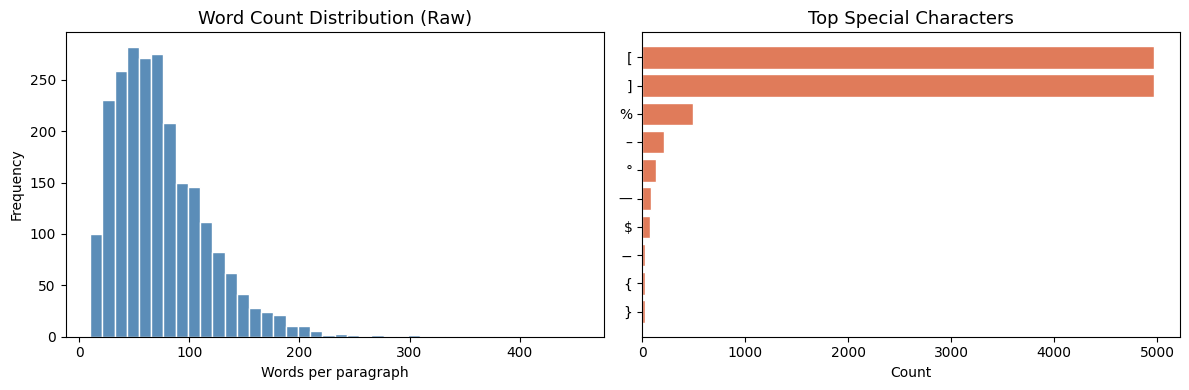


Word count → min:10 | median:67 | max:454


In [21]:
full_raw = " ".join(df["text"].tolist())

issues = {
    "Citations [n]"              : len(re.findall(r'\[\d+\]', full_raw)),
    "Stuck words (>14 chars)"    : len(re.findall(r'[a-z]{15,}', full_raw.lower())),
    "Missing space after '.'"    : len(re.findall(r'\.[A-Z]', full_raw)),
    "Missing space after ','"    : len(re.findall(r',[a-zA-Z]', full_raw)),
    "Special chars (%–°—${}...)" : len(re.findall(r'[%–—°$€£{}\\+=&×÷~−]', full_raw)),
}

print("=" * 45)
print("  RAW DATA ISSUES")
print("=" * 45)
for k, v in issues.items():
    print(f"  {k:<35} {v:>6,}")
print()

# Word count distribution
df["word_count_raw"] = df["text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["word_count_raw"], bins=40, color="#5B8DB8", edgecolor="white")
axes[0].set_title("Word Count Distribution (Raw)", fontsize=13)
axes[0].set_xlabel("Words per paragraph")
axes[0].set_ylabel("Frequency")

# Top special chars
specials = re.findall(r'[^\w\s.,;:!?()\-\'\"/ ]', full_raw)
top_sc = collections.Counter(specials).most_common(10)
chars, cnts = zip(*top_sc)
axes[1].barh(list(chars), list(cnts), color="#E07B5A", edgecolor="white")
axes[1].set_title("Top Special Characters", fontsize=13)
axes[1].set_xlabel("Count")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()
print(f"\nWord count → min:{df['word_count_raw'].min()} | "
      f"median:{df['word_count_raw'].median():.0f} | "
      f"max:{df['word_count_raw'].max()}")


## Stuck-Word Splitter (DP Segmentation)



In [ ]:
raw_words  = re.findall(r'\b[a-zA-Z]{2,14}\b', full_raw)
WORD_FREQ  = collections.Counter(w.lower() for w in raw_words)
TOTAL_FREQ = sum(WORD_FREQ.values())

print(f"Unique word types in corpus: {len(WORD_FREQ):,}")
print(f"Total word tokens:           {TOTAL_FREQ:,}")
print(f"Top 10 words: {WORD_FREQ.most_common(10)}")

Unique word types in corpus: 16,649
Total word tokens:           170,599
Top 10 words: [('the', 9802), ('of', 6266), ('and', 5400), ('to', 4526), ('in', 4423), ('is', 2125), ('that', 1597), ('for', 1581), ('as', 1570), ('are', 1448)]


In [ ]:
def word_log_prob(w: str) -> float:
    """Log-probability of a word based on corpus frequency"""
    return math.log(WORD_FREQ[w] / TOTAL_FREQ) if w in WORD_FREQ else -23.0


def dp_segment(token: str) -> list:
    """
    Viterbi DP word segmenter.
     'disposalincludes' → ['disposal', 'includes']
     corpus frequency — 
    """
    s = token.lower()
    n = len(s)
    best = [(0.0, 0)] + [(-math.inf, 0)] * n
    for i in range(1, n + 1):
        for j in range(max(0, i - 20), i):
            sc = best[j][0] + word_log_prob(s[j:i])
            if sc > best[i][0]:
                best[i] = (sc, j)
    parts, i = [], n
    while i > 0:
        j = best[i][1]
        parts.append(token[j:i])
        i = j
    return list(reversed(parts))


def fix_stuck_word(token: str) -> str:
    """
       token  .
         'environmentally'.
    """
    if len(token) <= 9 or not token.isalpha():
        return token.lower()
    parts = dp_segment(token)
    if len(parts) > 1 and all(len(p) >= 2 for p in parts):
        return " ".join(p.lower() for p in parts)
    return token.lower()


# Quick demo
demo_words = [
    "managementorwaste", "disposalincludes", "managewastefrom",
    "includingindustrial", "developedanddeveloping", "theenvironment",
    "thecollection", "reuseandrecycle", "lifecyclebegins",
    "environmentally",   
    "chlorofluorocarbons" 
]

print(f"{'Token':<35} {'Result':<35} {'Split?'}")
print("-" * 75)
for w in demo_words:
    result = fix_stuck_word(w)
    split  = "fixed" if " " in result else "— kept"
    print(f"{w:<35} {result:<35} {split}")

Token                               Result                              Split?
---------------------------------------------------------------------------
managementorwaste                   management or waste                 ✅ fixed
disposalincludes                    disposal includes                   ✅ fixed
managewastefrom                     manage waste from                   ✅ fixed
includingindustrial                 including industrial                ✅ fixed
developedanddeveloping              developed and developing            ✅ fixed
theenvironment                      the environment                     ✅ fixed
thecollection                       the collection                      ✅ fixed
reuseandrecycle                     reuse and recycle                   ✅ fixed
lifecyclebegins                     lifecycle begins                    ✅ fixed
environmentally                     environmentally                     — kept
chlorofluorocarbons                 chlorofluo


## Full Text Cleaning Pipeline

In [ ]:
def clean_text(raw: str) -> str:
    
    t = raw

    
    t = re.sub(r'\[\d+\]', ' ', t)
    t = re.sub(r'\[citation needed\]', ' ', t, flags=re.IGNORECASE)
    t = re.sub(r'\[[^\]]{0,40}\]', ' ', t)

    
    t = re.sub(r'\.([A-Z])', r'. \1', t)

    
    t = re.sub(r',([a-zA-Z])', r', \1', t)

    
    t = re.sub(r'[–—−]', ' ', t)

    
    t = re.sub(r'%', ' percent ', t)

    
    t = re.sub(r'[°$€£{}\\+=&×÷~@#^*<>|`]', ' ', t)

    
    t = re.sub(r'["\u201c\u201d\u201e]', '"', t)
    t = re.sub(r"[\u2018\u2019\u2032]", "'", t)

    
    t = re.sub(r'[^\x00-\x7F]+', ' ', t)

    
    fixed = []
    for tok in t.split():
        m = re.match(r'^([^a-zA-Z]*)([a-zA-Z][a-zA-Z]*)([^a-zA-Z]*)$', tok)
        if m:
            fixed.append(m.group(1) + fix_stuck_word(m.group(2)) + m.group(3))
        else:
            fixed.append(tok.lower())
    t = " ".join(fixed)

    
    t = t.lower()
    t = re.sub(r'\s+', ' ', t).strip()

    return t


print("Testing clean_text on a real row:")
print()
print("BEFORE:", df["text"].iloc[0][:300])
print()
print("AFTER: ", clean_text(df["text"].iloc[0])[:300])

Testing clean_text on a real row:

BEFORE: Waste managementorwaste disposalincludes the processes and actions required to managewastefrom its inception to its finaldisposal.[1]This includes thecollection,transport,treatment, and disposal of waste, together with monitoring and regulation of the waste management process and waste-relatedlaws, 

AFTER:  waste management or waste disposal includes the processes and actions required to manage waste from its inception to its finaldisposal. this includes the collection, transport, treatment, and disposal of waste, together with monitoring and regulation of the waste management process and waste-related


In [25]:
# Apply to all rows
print("Cleaning all rows...")
df["text_clean"] = df["text"].apply(clean_text)

# Remove very short rows after cleaning
before = len(df)
df = df[df["text_clean"].str.len() >= 80].reset_index(drop=True)
print(f"Removed {before - len(df)} too-short rows → {len(df):,} remaining")

# Measure improvement
full_clean = " ".join(df["text_clean"].tolist())
stuck_before = len(re.findall(r'\b[a-z]{15,}\b', full_raw.lower()))
stuck_after  = len(re.findall(r'\b[a-z]{15,}\b', full_clean))
cit_after    = len(re.findall(r'\[\d+\]', full_clean))

print()
print("=" * 45)
print("  CLEANING RESULTS")
print("=" * 45)
print(f"  Stuck tokens fixed : {stuck_before-stuck_after:,} / {stuck_before:,}  "
      f"({(stuck_before-stuck_after)/stuck_before*100:.0f}%)")
print(f"  Citations remaining: {cit_after}")
print(f"  Final rows         : {len(df):,}")

Cleaning all rows...
Removed 0 too-short rows → 2,336 remaining

  CLEANING RESULTS
  Stuck tokens fixed : 1,265 / 2,274  (56%)
  Citations remaining: 0
  Final rows         : 2,336


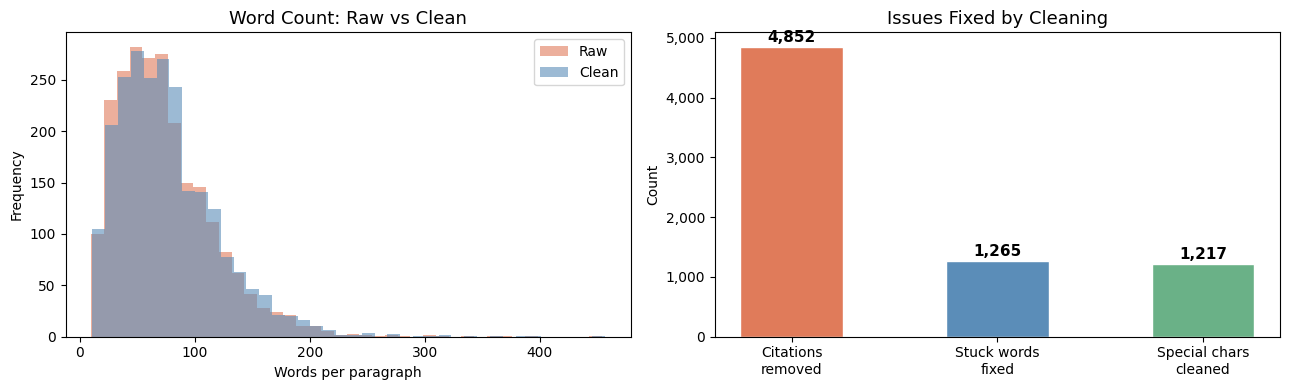

In [26]:
# Visualise before vs after
df["word_count_clean"] = df["text_clean"].str.split().str.len()
df["char_count_clean"] = df["text_clean"].str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["word_count_raw"],   bins=40, alpha=0.6, color="#E07B5A", label="Raw")
axes[0].hist(df["word_count_clean"], bins=40, alpha=0.6, color="#5B8DB8", label="Clean")
axes[0].set_title("Word Count: Raw vs Clean", fontsize=13)
axes[0].set_xlabel("Words per paragraph")
axes[0].set_ylabel("Frequency")
axes[0].legend()

metrics = ["Citations\nremoved", "Stuck words\nfixed", "Special chars\ncleaned"]
values  = [
    len(re.findall(r'\[\d+\]', full_raw)),
    stuck_before - stuck_after,
    len(re.findall(r'[%–—°$€£{}\\+=&×÷~−]', full_raw))
]
colors = ["#E07B5A", "#5B8DB8", "#6AB187"]
bars = axes[1].bar(metrics, values, color=colors, edgecolor="white", width=0.5)
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f"{val:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[1].set_title("Issues Fixed by Cleaning", fontsize=13)
axes[1].set_ylabel("Count")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()


## Tokenization & Vocabulary Building

In [ ]:
df["tokens"] = df["text_clean"].str.split()

all_tokens = [tok for row in df["tokens"] for tok in row]
token_freq = collections.Counter(all_tokens)

print(f"Total tokens   : {len(all_tokens):,}")
print(f"Unique types   : {len(token_freq):,}")
print(f"Type/Token ratio: {len(token_freq)/len(all_tokens):.4f}")
print()
print("Top 15 tokens:")
for w, c in token_freq.most_common(15):
    print(f"  {w:<20} {c:>6,}")

Total tokens   : 181,432
Unique types   : 27,265
Type/Token ratio: 0.1503

Top 15 tokens:
  the                   9,939
  of                    6,352
  and                   5,547
  to                    4,517
  in                    4,466
  a                     2,732
  is                    2,136
  that                  1,601
  as                    1,583
  for                   1,579
  are                   1,470
  by                    1,268
  from                  1,123
  with                  1,095
  on                      967


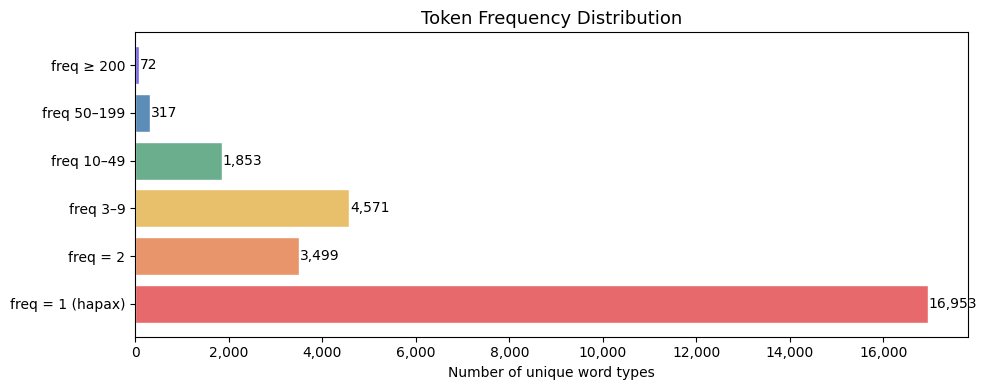

  freq = 1 (hapax)       16,953 types
  freq = 2                3,499 types
  freq 3–9                4,571 types
  freq 10–49              1,853 types
  freq 50–199               317 types
  freq ≥ 200                 72 types


In [ ]:
freq_bands = {
    "freq = 1 (hapax)"   : sum(1 for c in token_freq.values() if c == 1),
    "freq = 2"           : sum(1 for c in token_freq.values() if c == 2),
    "freq 3–9"           : sum(1 for c in token_freq.values() if 3 <= c <= 9),
    "freq 10–49"         : sum(1 for c in token_freq.values() if 10 <= c <= 49),
    "freq 50–199"        : sum(1 for c in token_freq.values() if 50 <= c <= 199),
    "freq ≥ 200"         : sum(1 for c in token_freq.values() if c >= 200),
}

fig, ax = plt.subplots(figsize=(10, 4))
colors_fb = ["#E8696B", "#E8956B", "#E8C06B", "#6BAE8E", "#5B8DB8", "#7B6BE8"]
bars = ax.barh(list(freq_bands.keys()), list(freq_bands.values()),
               color=colors_fb, edgecolor="white")
for bar, val in zip(bars, freq_bands.values()):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=10)
ax.set_title("Token Frequency Distribution", fontsize=13)
ax.set_xlabel("Number of unique word types")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

for k, v in freq_bands.items():
    print(f"  {k:<22} {v:>6,} types")

In [29]:
# Build vocabulary with min_freq filter
vocab_words = [w for w, c in token_freq.most_common() if c >= MIN_FREQ]
vocab       = [PAD, UNK, BOS, EOS] + vocab_words
word2idx    = {w: i for i, w in enumerate(vocab)}
idx2word    = {i: w for w, i in word2idx.items()}

unk_idx = word2idx[UNK]
pad_idx = word2idx[PAD]
bos_idx = word2idx[BOS]
eos_idx = word2idx[EOS]

# Coverage stats
covered  = sum(token_freq[w] for w in vocab_words)
coverage = covered / len(all_tokens) * 100
oov_types = sum(1 for w in token_freq if w not in word2idx)

print("=" * 45)
print("  VOCABULARY STATS")
print("=" * 45)
print(f"  Vocab size       : {len(vocab):,}  (incl. 4 special tokens)")
print(f"  OOV types → UNK  : {oov_types:,}")
print(f"  Token coverage   : {coverage:.1f}%")
print(f"  PAD idx          : {pad_idx}")
print(f"  UNK idx          : {unk_idx}")
print(f"  BOS idx          : {bos_idx}")
print(f"  EOS idx          : {eos_idx}")

  VOCABULARY STATS
  Vocab size       : 6,817  (incl. 4 special tokens)
  OOV types → UNK  : 20,452
  Token coverage   : 86.8%
  PAD idx          : 0
  UNK idx          : 1
  BOS idx          : 2
  EOS idx          : 3


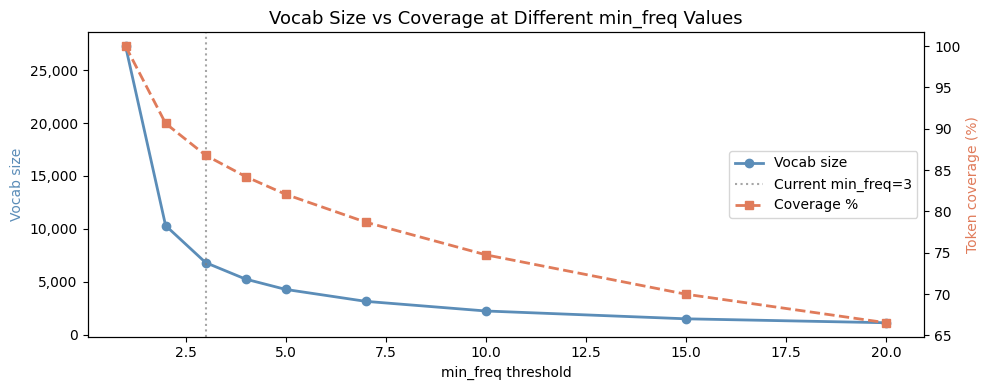

In [30]:
# Visualise vocab coverage vs min_freq threshold
thresholds = [1, 2, 3, 4, 5, 7, 10, 15, 20]
vocab_sizes, coverages = [], []

for thresh in thresholds:
    vw = [w for w, c in token_freq.items() if c >= thresh]
    vocab_sizes.append(len(vw))
    coverages.append(sum(token_freq[w] for w in vw) / len(all_tokens) * 100)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

ax1.plot(thresholds, vocab_sizes, "o-", color="#5B8DB8", lw=2, label="Vocab size")
ax2.plot(thresholds, coverages,   "s--", color="#E07B5A", lw=2, label="Coverage %")

ax1.axvline(MIN_FREQ, color="gray", linestyle=":", alpha=0.7, label=f"Current min_freq={MIN_FREQ}")

ax1.set_xlabel("min_freq threshold")
ax1.set_ylabel("Vocab size", color="#5B8DB8")
ax2.set_ylabel("Token coverage (%)", color="#E07B5A")
ax1.set_title("Vocab Size vs Coverage at Different min_freq Values", fontsize=13)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

plt.tight_layout()
plt.show()


## Encode Corpus to Integer Sequences

In [ ]:
def encode_row(tokens: list) -> list:
    
    return [word2idx.get(tok, unk_idx) for tok in tokens]

df["encoded"] = df["tokens"].apply(encode_row)


full_seq = (
    [bos_idx]
    + [idx for row in df["encoded"] for idx in row]
    + [eos_idx]
)

print(f"Full encoded sequence length: {len(full_seq):,} tokens")
print(f"Sample (first 20):            {full_seq[:20]}")
print(f"Decoded back:                 {[idx2word[i] for i in full_seq[:20]]}")

Full encoded sequence length: 181,434 tokens
Sample (first 20):            [2, 22, 110, 21, 22, 237, 427, 4, 357, 6, 1201, 401, 7, 1879, 22, 16, 57, 1, 7, 57]
Decoded back:                 ['<BOS>', 'waste', 'management', 'or', 'waste', 'disposal', 'includes', 'the', 'processes', 'and', 'actions', 'required', 'to', 'manage', 'waste', 'from', 'its', '<UNK>', 'to', 'its']



## Sliding Window — Create RNN Sequences

In [ ]:
def make_sequences(token_ids: list, seq_len: int, overlap: float):
   
    step = max(1, int(seq_len * (1 - overlap)))
    X, y = [], []
    for i in range(0, len(token_ids) - seq_len, step):
        x_seq = token_ids[i     : i + seq_len]
        y_seq = token_ids[i + 1 : i + seq_len + 1]
        if len(x_seq) == seq_len and len(y_seq) == seq_len:
            X.append(x_seq)
            y.append(y_seq)
    return np.array(X, dtype=np.int32), np.array(y, dtype=np.int32)


X, y = make_sequences(full_seq, SEQ_LEN, OVERLAP)
print(f"Total sequences : {len(X):,}")
print(f"X shape         : {X.shape}   (samples × seq_len)")
print(f"y shape         : {y.shape}")
print()
print("Sample X[0] decoded:", [idx2word[i] for i in X[0][:10]], "...")
print("Sample y[0] decoded:", [idx2word[i] for i in y[0][:10]], "...")

Total sequences : 7,256
X shape         : (7256, 50)   (samples × seq_len)
y shape         : (7256, 50)

Sample X[0] decoded: ['<BOS>', 'waste', 'management', 'or', 'waste', 'disposal', 'includes', 'the', 'processes', 'and'] ...
Sample y[0] decoded: ['waste', 'management', 'or', 'waste', 'disposal', 'includes', 'the', 'processes', 'and', 'actions'] ...



## Train / Validation Split

  TRAIN / VAL SPLIT
  X_train : (6530, 50)
  y_train : (6530, 50)
  X_val   : (726, 50)
  y_val   : (726, 50)


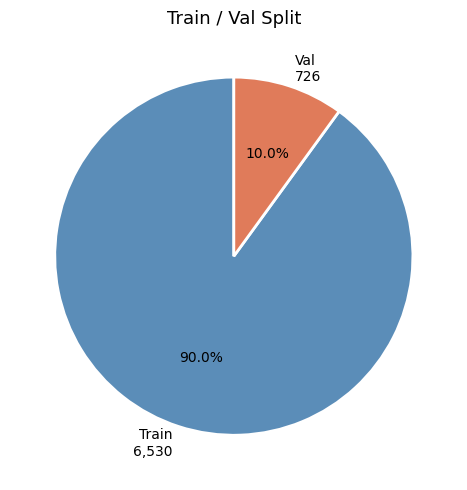

In [33]:
split_at = int(len(X) * TRAIN_SPLIT)

X_train, X_val = X[:split_at],  X[split_at:]
y_train, y_val = y[:split_at],  y[split_at:]

print("=" * 45)
print("  TRAIN / VAL SPLIT")
print("=" * 45)
print(f"  X_train : {X_train.shape}")
print(f"  y_train : {y_train.shape}")
print(f"  X_val   : {X_val.shape}")
print(f"  y_val   : {y_val.shape}")

# Pie chart
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    [len(X_train), len(X_val)],
    labels=[f"Train\n{len(X_train):,}", f"Val\n{len(X_val):,}"],
    colors=["#5B8DB8", "#E07B5A"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
ax.set_title("Train / Val Split", fontsize=13)
plt.tight_layout()
plt.show()


## Save Outputs

In [ ]:
np.savez_compressed(
    "rnn_ready.npz",
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val
)


vocab_data = {
    "vocab_size"     : len(vocab),
    "special_tokens" : {PAD: 0, UNK: 1, BOS: 2, EOS: 3},
    "word2idx"       : word2idx,
    "idx2word"       : {str(k): v for k, v in idx2word.items()},
    "config"         : {
        "seq_len"      : SEQ_LEN,
        "min_freq"     : MIN_FREQ,
        "train_split"  : TRAIN_SPLIT,
        "total_tokens" : len(all_tokens),
        "coverage_pct" : round(coverage, 2)
    }
}
with open("vocab.json", "w", encoding="utf-8") as f:
    json.dump(vocab_data, f, ensure_ascii=False, indent=2)


with open("clean_corpus.txt", "w", encoding="utf-8") as f:
    for row in df["text_clean"]:
        f.write(row + "\n")

print("Saved:")
print("   rnn_ready.npz       X_train, y_train, X_val, y_val")
print("   vocab.json          word2idx + idx2word + config")
print("   clean_corpus.txt  ")

💾 Saved:
   rnn_ready.npz      ← X_train, y_train, X_val, y_val
   vocab.json         ← word2idx + idx2word + config
   clean_corpus.txt   ← النص النظيف كاملاً



## Final Summary

In [ ]:
print("=" * 50)
print("  PREPROCESSING PIPELINE — FINAL SUMMARY")
print("=" * 50)
print(f"  Input rows           : {len(df):,}")
print(f"  Total tokens (clean) : {len(all_tokens):,}")
print(f"  Vocab size           : {len(vocab):,}")
print(f"  Token coverage       : {coverage:.1f}%")
print(f"  Sequence length      : {SEQ_LEN}")
print(f"  Train sequences      : {len(X_train):,}")
print(f"  Val sequences        : {len(X_val):,}")
print(f"  X_train shape        : {X_train.shape}")
print("=" * 50)
print("Data is ready for RNN / LSTM / GRU training")

  PREPROCESSING PIPELINE — FINAL SUMMARY
  Input rows           : 2,336
  Total tokens (clean) : 181,432
  Vocab size           : 6,817
  Token coverage       : 86.8%
  Sequence length      : 50
  Train sequences      : 6,530
  Val sequences        : 726
  X_train shape        : (6530, 50)
✅ Data is ready for RNN / LSTM / GRU training!
